Confusion Matrix:
 [[13  0  0]
 [ 0 16  0]
 [ 0  0  9]]

Values:
TP = 13
TN = 25
FP = 0
FN = 0

Performance Metrics:
Accuracy = 1.0
Error Rate = 0.0
Precision = 1.0
Recall = 1.0


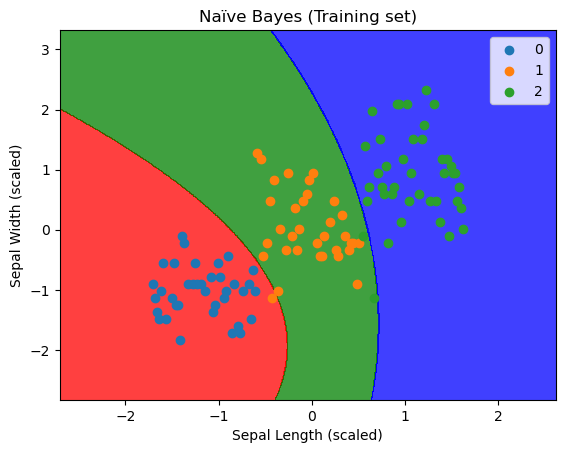

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from matplotlib.colors import ListedColormap

# Load dataset
df = pd.read_csv('/home/armanshaikh/Downloads/Iris.csv')

# Features (only 2 for graph)
X = df.iloc[:, [0, 1]].values

# Convert string labels to numbers
le = LabelEncoder()
y = le.fit_transform(df.iloc[:, -1])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# Feature scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Train model
model = GaussianNB()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Convert multi-class → binary (class 0 vs rest)
TP = cm[0][0]
FP = cm[:, 0].sum() - TP
FN = cm[0].sum() - TP
TN = cm.sum() - (TP + FP + FN)

# Metrics
accuracy = (TP + TN) / cm.sum()
error_rate = (FP + FN) / cm.sum()
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0

print("\nValues:")
print("TP =", TP)
print("TN =", TN)
print("FP =", FP)
print("FN =", FN)

print("\nPerformance Metrics:")
print("Accuracy =", round(accuracy, 4))
print("Error Rate =", round(error_rate, 4))
print("Precision =", round(precision, 4))
print("Recall =", round(recall, 4))

# -------------------------------
# Graph (Decision Boundary)
# -------------------------------
X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1,
              stop=X_set[:, 0].max() + 1,
              step=0.01),
    np.arange(start=X_set[:, 1].min() - 1,
              stop=X_set[:, 1].max() + 1,
              step=0.01)
)

plt.contourf(
    X1, X2,
    model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green', 'blue'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Plot points
for i in np.unique(y_set):
    plt.scatter(
        X_set[y_set == i, 0],
        X_set[y_set == i, 1],
        label=i
    )

plt.title('Naïve Bayes (Training set)')
plt.xlabel('Sepal Length (scaled)')
plt.ylabel('Sepal Width (scaled)')
plt.legend()
plt.show()